In [54]:
import os

! pip install tensorflow==2.4.0

# Tensorflow is an open-source ML lib
import tensorflow as tf

# Keras is Tensorflow's high-level API for deep learning
from tensorflow import keras

# Numpy is a math lib
import numpy as np

# Panda is a data manipulation lib
import pandas as pd

# Matplotlib is a graphing lib
import matplotlib.pyplot as plt

# Math is Python's math lib
import math

# Set seed for experimental reproducibility
seed = 1
np.random.seed(seed)
tf.random.set_seed(seed)

CIRCLES_OS_PATH = 'circles/'
RECTANGLES_OS_PATH = 'rectangles/'
TRIANGLES_OS_PATH = 'triangles/'

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try 'pacman -S
    python-xyz', where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Arch-packaged Python package,
    create a virtual environment using 'python -m venv path/to/venv'.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip.
    
    If you wish to install a non-Arch packaged Python application,
    it may be easiest to use 'pipx install xyz', which will manage a
    virtual environment for you. Make sure you have python-pipx
    installed via pacman.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detailed specification.


## Create Shapes (Data Augmentation)

## Helpers

In the below cell we define some helper functions for creating the dataset.

[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0]
 [0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0]
 [0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0]
 [0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0]
 [0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0]
 [0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0]
 [0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0]
 [0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0]
 [0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1]
 [0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 

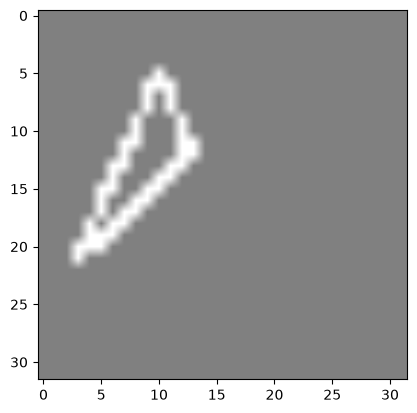

In [82]:
SAMPLES = 1000
WIDTH = 32
HEIGHT = 32

class Point:
    x = 0
    y = 0
    def __init__(self, x, y):
        self.x = x
        self.y = y

screen = np.zeros((HEIGHT, WIDTH), dtype=np.int8)
np.set_printoptions(threshold=np.inf)

def clear_screen():
    global screen
    screen = np.zeros((HEIGHT, WIDTH), dtype=np.int8)

def linear_interpolation(start, end, t):
    return (1-t)*start + t*end

def generate_circle(point, radius, file_name):
    current_x = math.cos(0)
    current_y = math.sin(0)
    angle = 0
    while angle <= (math.pi*2):
        index_x = round((current_x*radius)+point.x)
        index_y = round((current_y*radius)+point.y)
        if not(index_x >= WIDTH or index_x < 0 or index_y >= HEIGHT or index_y < 0):     
            screen[index_x][index_y] = 1
            current_x = math.cos(angle)
            current_y = math.sin(angle)
            angle += 0.05
    
    with open(os.path.join(CIRCLES_OS_PATH, file_name), 'w') as fp:
        pass

    np.savetxt(os.path.join(CIRCLES_OS_PATH, file_name), screen, fmt="%d")        

def generate_line(start_point, end_point):
    t = 0

    while t <= 1:
        index_x = round(linear_interpolation(start_point.x, end_point.x, t))
        index_y = round(linear_interpolation(start_point.y, end_point.y, t))
        if not(index_x >= WIDTH or index_x < 0 or index_y >= HEIGHT or index_y < 0): 
            screen[index_x][index_y] = 1
        t += 0.01

def generate_rectangle(top_left, bottom_right, file_name):
    # Top Line
    generate_line(top_left, Point(bottom_right.x, top_left.y))
    # Bottom Line
    generate_line(Point(top_left.x, bottom_right.y), bottom_right)
    #Right Line
    generate_line(top_left, Point(top_left.x, bottom_right.y))
    #Left Line
    generate_line(Point(bottom_right.x, top_left.y), bottom_right)
    with open(os.path.join(RECTANGLES_OS_PATH, file_name), 'w') as fp:
        pass

    np.savetxt(os.path.join(RECTANGLES_OS_PATH, file_name), screen, fmt="%d")  

def generate_triangle(vertex_1, vertex_2, vertex_3, file_name):
    generate_line(vertex_1, vertex_2)
    generate_line(vertex_2, vertex_3)
    generate_line(vertex_3, vertex_1)
    with open(os.path.join(TRIANGLES_OS_PATH, file_name), 'w') as fp:
        pass

    np.savetxt(os.path.join(TRIANGLES_OS_PATH, file_name), screen, fmt="%d")  

generate_circle(Point(math.floor(WIDTH/2),math.floor(HEIGHT/2)),15,'test.cir')
print(screen)
plt.imshow(screen, interpolation='bilinear', cmap='gray', vmax=abs(screen).max(), vmin=-abs(screen).max())

clear_screen()

generate_line(Point(0,0),Point(31,31))
print(screen)
plt.imshow(screen, interpolation='bilinear', cmap='gray', vmax=abs(screen).max(), vmin=-abs(screen).max())

clear_screen()

generate_rectangle(Point(0,0),Point(31,31), 'test.rec')
print(screen)
plt.imshow(screen, interpolation='bilinear', cmap='gray', vmax=abs(screen).max(), vmin=-abs(screen).max())

clear_screen()

generate_triangle(Point(12,13),Point(21,3),Point(5, 10), 'test.tri')
print(screen)
plt.imshow(screen, interpolation='bilinear', cmap='gray', vmax=abs(screen).max(), vmin=-abs(screen).max())